In [61]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "-BZITnY_s_YijW3jrGyzuOgiQxxMtXEU9U_yxpBLYlUiPZw0kKvethzTBR2A4NqZuVVw-2bKQ70rDUuPgNCQJQ=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [62]:
time_start = "-5m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-6]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)

In [63]:
print(df_sensor_data.head())

    result  table                            _time  \
0  _result      0 2026-04-21 07:36:42.197609+00:00   
1  _result      0 2026-04-21 07:36:42.247204+00:00   
2  _result      0 2026-04-21 07:36:42.299620+00:00   
3  _result      0 2026-04-21 07:36:42.351463+00:00   
4  _result      0 2026-04-21 07:36:42.401355+00:00   

                            _start                            _stop  \
0 2026-04-21 07:36:42.175135+00:00 2026-04-21 07:41:42.175135+00:00   
1 2026-04-21 07:36:42.175135+00:00 2026-04-21 07:41:42.175135+00:00   
2 2026-04-21 07:36:42.175135+00:00 2026-04-21 07:41:42.175135+00:00   
3 2026-04-21 07:36:42.175135+00:00 2026-04-21 07:41:42.175135+00:00   
4 2026-04-21 07:36:42.175135+00:00 2026-04-21 07:41:42.175135+00:00   

  _measurement     source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  pt_mockup          0.000004          0.000002   
1  sensor_data  pt_mockup          0.000004          0.000002   
2  sensor_data  pt_mockup          0.000003          

In [64]:
q_tags = [f"q_actual_joint_{i}" for i in range(6)]

q_tags.append("_time")

df_pos = df_sensor_data[q_tags].copy()

print(df_pos.head())

   q_actual_joint_0  q_actual_joint_1  q_actual_joint_2  q_actual_joint_3  \
0          0.000004          0.000002      6.098170e-07         -0.000006   
1          0.000004          0.000002      6.985226e-07         -0.000005   
2          0.000003          0.000002      7.099048e-07         -0.000005   
3          0.000003          0.000002      8.058130e-07         -0.000005   
4          0.000003          0.000002      8.725561e-07         -0.000005   

   q_actual_joint_4  q_actual_joint_5                            _time  
0         -0.000002     -8.553756e-07 2026-04-21 07:36:42.197609+00:00  
1         -0.000002     -9.993762e-07 2026-04-21 07:36:42.247204+00:00  
2         -0.000002     -9.082626e-07 2026-04-21 07:36:42.299620+00:00  
3         -0.000002     -9.150423e-07 2026-04-21 07:36:42.351463+00:00  
4         -0.000001     -9.237204e-07 2026-04-21 07:36:42.401355+00:00  


In [65]:
qd_tags = [f"qd_actual_joint_{i}" for i in range(6)]

qd_tags.append("_time")

df_vel = df_sensor_data[qd_tags].copy()

print(df_vel.head())

   qd_actual_joint_0  qd_actual_joint_1  qd_actual_joint_2  qd_actual_joint_3  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2                0.0                0.0                0.0                0.0   
3                0.0                0.0                0.0                0.0   
4                0.0                0.0                0.0                0.0   

   qd_actual_joint_4  qd_actual_joint_5                            _time  
0                0.0                0.0 2026-04-21 07:36:42.197609+00:00  
1                0.0                0.0 2026-04-21 07:36:42.247204+00:00  
2                0.0                0.0 2026-04-21 07:36:42.299620+00:00  
3                0.0                0.0 2026-04-21 07:36:42.351463+00:00  
4                0.0                0.0 2026-04-21 07:36:42.401355+00:00  


# Velocity Profile

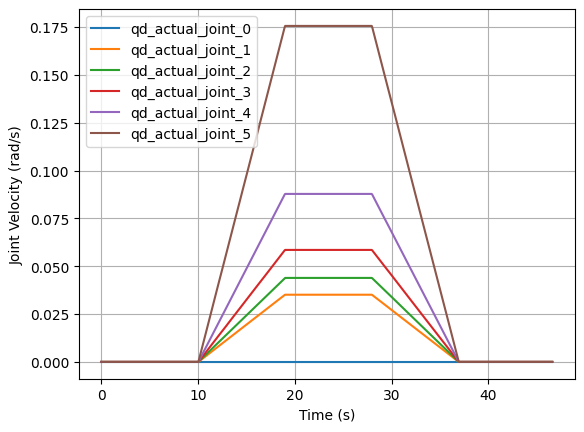

In [75]:
df_vel_trunk = df_vel.iloc[970:1900]
np_vel = df_vel_trunk.to_numpy()
time_series = df_vel_trunk["_time"]
norm_time = (time_series - time_series.iloc[0]).dt.total_seconds().to_numpy()

for joint in range(6):
    plt.plot(norm_time, np_vel[:, joint], label=f"qd_actual_joint_{joint}")

plt.xlabel("Time (s)")
plt.ylabel("Joint Velocity (rad/s)")
plt.grid()
plt.legend()

# Position Profile

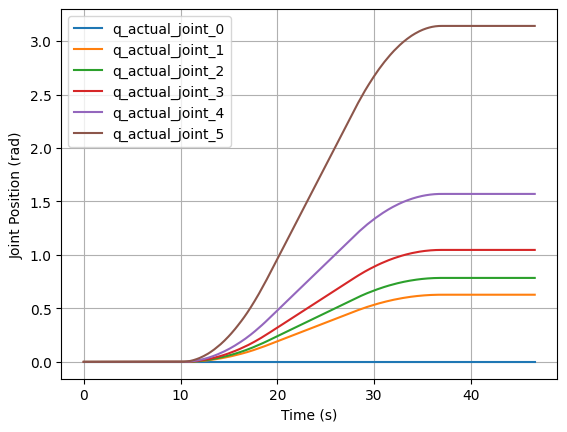

In [76]:
df_pos_trunk = df_pos.iloc[970:1900]
np_pos = df_pos_trunk.to_numpy()
time_series = df_pos_trunk["_time"]
norm_time = (time_series - time_series.iloc[0]).dt.total_seconds().to_numpy()

for joint in range(6):
    plt.plot(norm_time, np_pos[:, joint], label=f"q_actual_joint_{joint}")

plt.xlabel("Time (s)")
plt.ylabel("Joint Position (rad)")
plt.grid()
plt.legend()